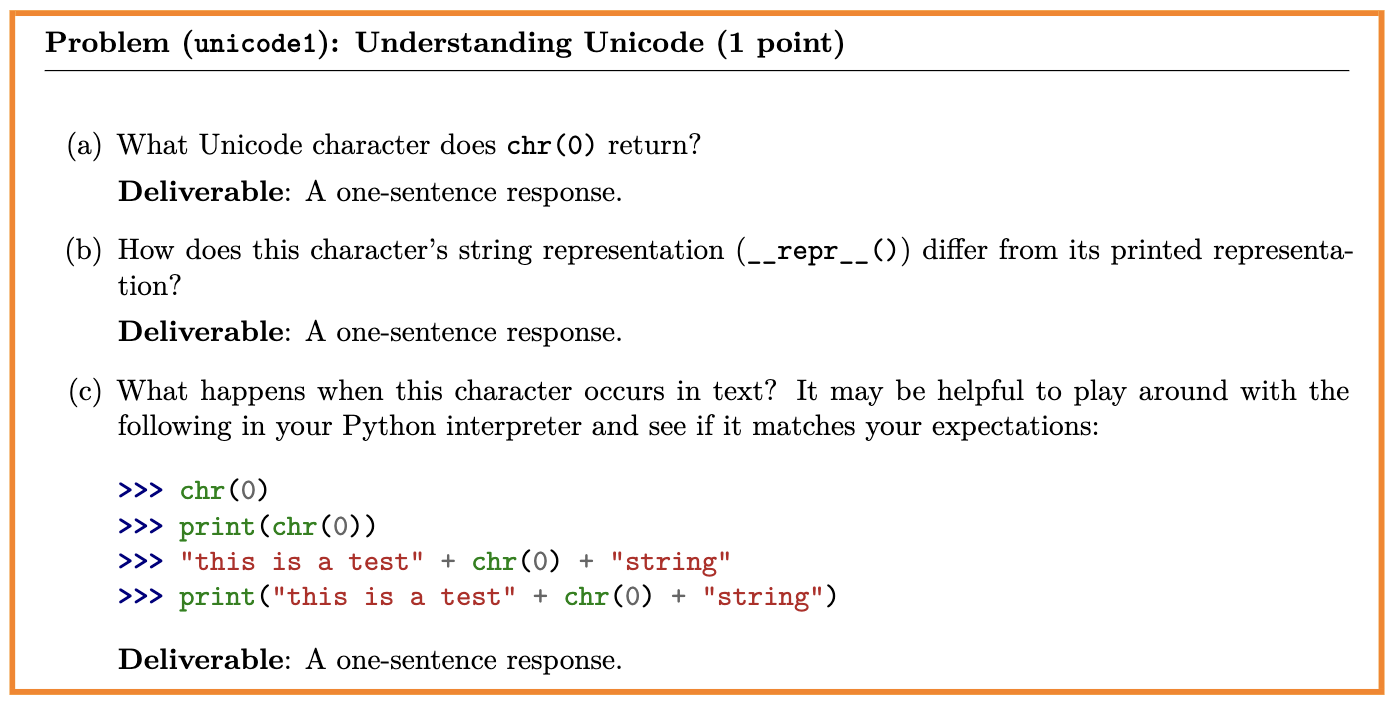

In [6]:
print(chr(0))
print(str.__repr__(chr(0)))
print("this is a test" + chr(0) + "string")

 
'\x00'
this is a test string


- (a) `char(0)` returns a `NULL`.
- (b) `str.__repr__(char(0))` returns the hexadecimal byte representation of the character, which is `'\x00'`.
- (c) `char(0)` will not display anything in the output.

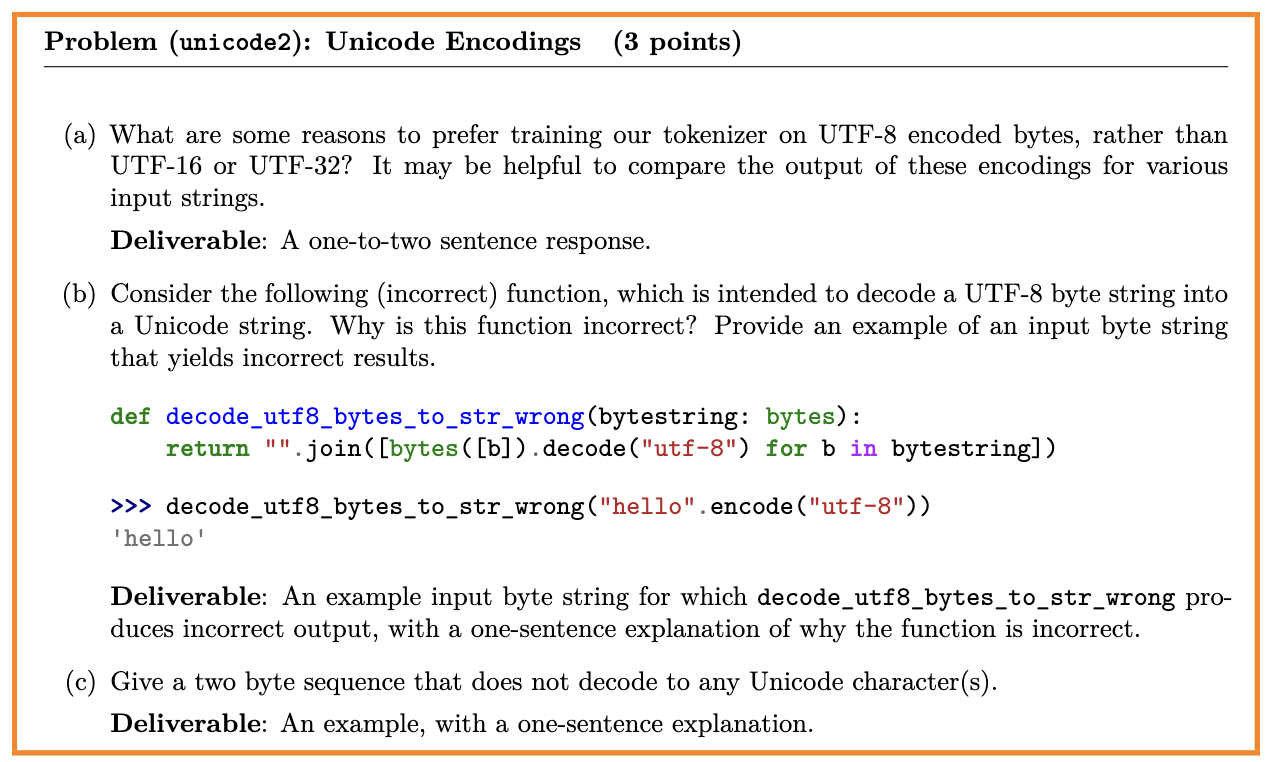

In [24]:
test_string = "hello! こんにちは!"
utf8_encoded = test_string.encode('utf-8')
utf16_encoded = test_string.encode('utf-16')
utf32_encoded = test_string.encode('utf-32')
print(utf8_encoded)
print(utf16_encoded)
print(utf32_encoded)
print(list(utf8_encoded))
print(len(list(utf8_encoded)))
print(list(utf16_encoded))
print(len(list(utf16_encoded)))
print(list(utf32_encoded))
print(len(list(utf32_encoded)))

def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode('utf-8') for b in bytestring])

# print(decode_utf8_bytes_to_str_wrong(utf8_encoded))

# print(b'\xc0\x80'.decode('utf-8'))
print(b'\xc2\x80'.decode('utf-8'))

b'hello! \xe3\x81\x93\xe3\x82\x93\xe3\x81\xab\xe3\x81\xa1\xe3\x81\xaf!'
b'\xff\xfeh\x00e\x00l\x00l\x00o\x00!\x00 \x00S0\x930k0a0o0!\x00'
b'\xff\xfe\x00\x00h\x00\x00\x00e\x00\x00\x00l\x00\x00\x00l\x00\x00\x00o\x00\x00\x00!\x00\x00\x00 \x00\x00\x00S0\x00\x00\x930\x00\x00k0\x00\x00a0\x00\x00o0\x00\x00!\x00\x00\x00'
[104, 101, 108, 108, 111, 33, 32, 227, 129, 147, 227, 130, 147, 227, 129, 171, 227, 129, 161, 227, 129, 175, 33]
23
[255, 254, 104, 0, 101, 0, 108, 0, 108, 0, 111, 0, 33, 0, 32, 0, 83, 48, 147, 48, 107, 48, 97, 48, 111, 48, 33, 0]
28
[255, 254, 0, 0, 104, 0, 0, 0, 101, 0, 0, 0, 108, 0, 0, 0, 108, 0, 0, 0, 111, 0, 0, 0, 33, 0, 0, 0, 32, 0, 0, 0, 83, 48, 0, 0, 147, 48, 0, 0, 107, 48, 0, 0, 97, 48, 0, 0, 111, 48, 0, 0, 33, 0, 0, 0]
56



- (a) Using UTF-8 encoding, for the same string, the byte sequence will be shorter than UTF-16 and UTF-32, which will save more storage space. What's more，UTF-8 is backward compatible with ASCII, so it can represent all ASCII characters using a single byte.
- (b) This function attempts to decode UTF-8 byte string using bytes one by one, but UTF-8 is a variable-length encoding scheme, so it may require multiple bytes to represent a single character.
- (c) `\xc0\x80`. Two byte UTF-8 encoding's scope is from U+0080 to U+07FF.

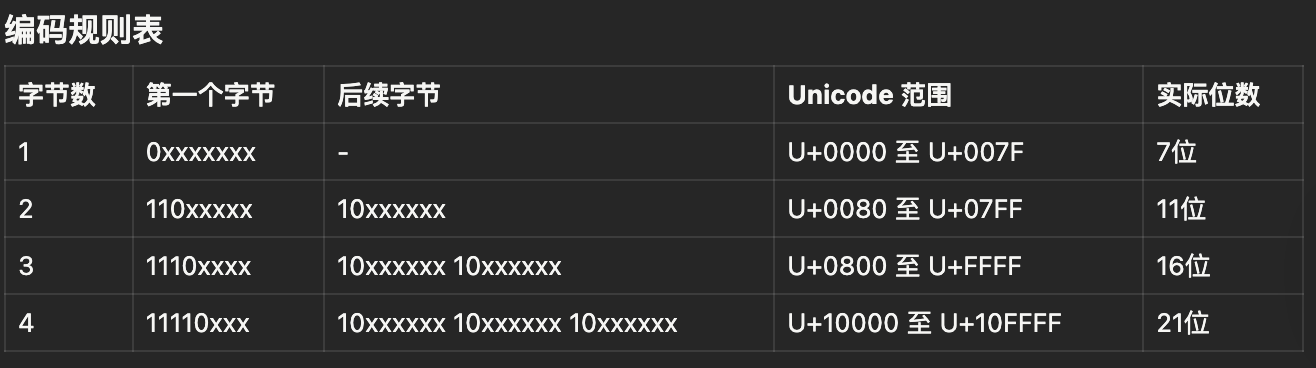
每个符号编码后第一个字节的高端bit位用于表示总共有多少编码个字节，后续的每个高端bit都以10开头。

## word-level tokenizers vs byte-level tokenizers:
- word-level: much larger vocabulary; out of vocabulary
- byte-level: 256-sized vocabulary; no out of vocabulary; but more tokens for the same text

```python

## BPE Tokenizer
### three main steps:
1. Vocabulary initialization: initial vocabulary is simply the set of all
bytes(size 256) 
2. Pre-tokenization: count how often bytes occur next
to each other in your text and begin merging them starting with the most frequent pair of bytes
    - Problem: However,this is quite computationally expensive, since we’d have to go take a full pass over the corpus each time we merge. In addition, directly merging bytes across the corpus may result in tokens that differ only in punctuation (e.g., dog! vs. dog.). These tokens would get completely different token IDs, even though they are likely to have high semantic similarity (since they differ only in punctuation).
    - To avoid this, we pre-tokenize the corpus. You can think of this as a coarse-grained tokenization over the corpus that helps us count how often pairs of characters appear. For example, the word 'text' might be a pre-token that appears 10 times. In this case, when we count how often the characters ‘t’ and ‘e’ appear next to each other, we will see that the word ‘text’ has ‘t’ and ‘e’ adjacent and we can increment their count by 10 instead of looking through the corpus. 
    - regex-based pre-tokenizer (used by GPT-2)
3. Compute BPE merges: the BPE algorithm iteratively counts every pair of bytes and identifies the pair with the highest frequency (“A”, “B”). Every occurrence of this most frequent pair (“A”, “B”) is then merged. For eﬀiciency during BPE training, we do not consider pairs that cross pre-token boundaries. When computing merges, deterministically break ties in pair frequency by preferring the lexicographically greater pair.

### Special tokens 
Often, some strings (e.g., <|endoftext|>) are used to encode metadata (e.g., boundaries between documents). When encoding text, it’s often desirable to treat some strings as “special tokens” that should never be split into multiple tokens (i.e., will always be preserved as a single token).